In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

import matplotlib.pyplot as plt

In [2]:
file = Path("../data/repeated_10_scale_250/123824_repeated10_scale250.graphml")


In [3]:
node_num_cols = [
    "dn_position_x", "dn_position_y", "dn_position_z", "dn_correspondence_id"
]

edge_num_cols = [
    "fiber_length_mean", "FA_mean", "number_of_fibers"
]

G = nx.read_graphml(file)

node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append({
        "file": file.name,
        "path": str(file),
        "node_id": node_id,
        **attrs
    })

nodes_df = pd.DataFrame(node_records)

for col in node_num_cols:
    if col in nodes_df.columns:
        nodes_df[col] = pd.to_numeric(nodes_df[col], errors="coerce")

edge_records = []
for u, v, attrs in G.edges(data=True):
    edge_records.append({
        "file": file.name,
        "path": str(file),
        "source": u,
        "target": v,
        **attrs
    })

edges_df = pd.DataFrame(edge_records)

for col in edge_num_cols:
    if col in edges_df.columns:
        edges_df[col] = pd.to_numeric(edges_df[col])


In [4]:
display(nodes_df.head())
display(edges_df.head())


,file,path,node_id,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere
0,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,1,36.060150,72.007519,19.789474,1,cortical,lateralorbitofrontal_1,rh.lateralorbitofrontal_1,right
1,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,32.323529,75.549020,26.019608,2,cortical,lateralorbitofrontal_2,rh.lateralorbitofrontal_2,right
2,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,3,30.841924,76.659794,21.446735,3,cortical,lateralorbitofrontal_3,rh.lateralorbitofrontal_3,right
3,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,4,37.600000,76.954167,20.033333,4,cortical,lateralorbitofrontal_4,rh.lateralorbitofrontal_4,right
4,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,5,37.430769,81.333333,20.169231,5,cortical,lateralorbitofrontal_5,rh.lateralorbitofrontal_5,right


,file,path,source,target,fiber_length_mean,FA_mean,number_of_fibers
0,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,225,34.135386,0.148843,9.875
1,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,226,15.406211,0.131813,63.000
2,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,85,35.333331,0.160492,5.375
3,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,25,36.812499,0.139836,1.625
4,123824_repeated10_scale250.graphml,../data/repeated_10_scale_250/123824_repeated1...,2,26,31.414687,0.141333,7.375


In this section we load one structural brain graph and inspect whether it shows
a visible community structure. We then project the detected communities into the
anatomical 3D coordinates provided in the node attributes.

In [5]:
G_und = nx.Graph(G)

communities = list(greedy_modularity_communities(G_und))
print("Number of communities found:", len(communities))

Number of communities found: 77


In [6]:
community_map = {}

for i, comm in enumerate(communities):
    for node in comm:
        community_map[str(node)] = i

In [7]:
nodes_df["node_id"] = nodes_df["node_id"].astype(str)
nodes_df["community"] = nodes_df["node_id"].map(community_map)

display(nodes_df[["node_id", "community"]].head())

,node_id,community
0,1,3
1,2,1
2,3,4
3,4,5
4,5,6


In [8]:
community_sizes = nodes_df["community"].value_counts().sort_index()
display(community_sizes)

community
0     194
1     189
2       6
3       1
4       1
     ... 
72      1
73      1
74      1
75      1
76      1
Name: count, Length: 77, dtype: int64

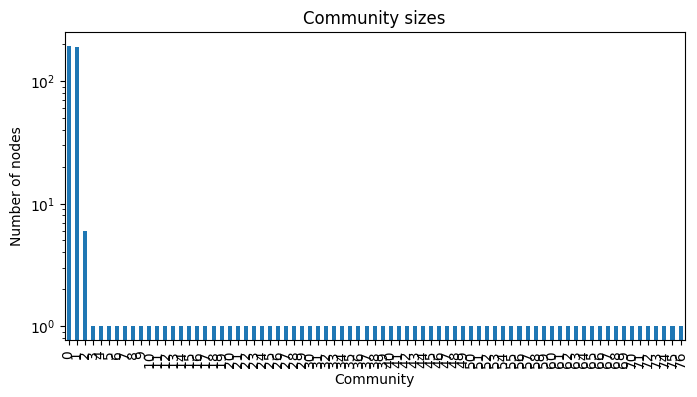

In [9]:
community_sizes.plot(kind="bar", figsize=(8,4))
plt.xlabel("Community")
plt.ylabel("Number of nodes")
plt.yscale('log')
plt.title("Community sizes")
plt.show()

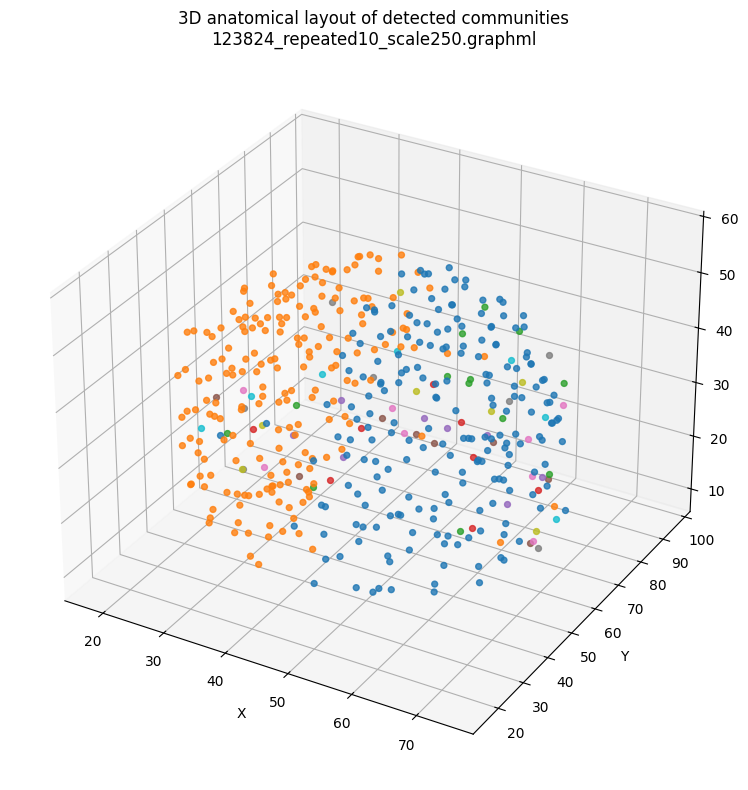

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for comm_id in sorted(nodes_df["community"].dropna().unique()):
    subset = nodes_df[nodes_df["community"] == comm_id]
    ax.scatter(
        subset["dn_position_x"],
        subset["dn_position_y"],
        subset["dn_position_z"],
        label=f"C{int(comm_id)}",
        s=18,
        alpha=0.8
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"3D anatomical layout of detected communities\n{file.name}")
plt.tight_layout()
plt.show()

We applied community detection to the structural brain network and visualized the resulting clusters in anatomical 3D space. The observed spatial localization of several communities suggests that the graph exhibits non-random modular structure, reflecting the underlying organization of brain connectivity.

In [11]:
print("File:", file.name)
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Number of detected communities:", len(communities))
print("Largest community size:", community_sizes.max())
print("Smallest community size:", community_sizes.min())

File: 123824_repeated10_scale250.graphml
Number of nodes: 463
Number of edges: 6839
Number of detected communities: 77
Largest community size: 194
Smallest community size: 1


We now use the empirical brain connectivity graph as the reservoir connectivity matrix and inspect the resulting dynamics over time. The goal is to understand whether the activity remains stable, spreads broadly across neurons, or develops structured temporal patterns.

In [12]:
node_list = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(node_list)}

N = len(node_list)
W = np.zeros((N, N))

for u, v, attrs in G.edges(data=True):
    i = node_to_idx[u]
    j = node_to_idx[v]
    
    weight = float(attrs.get("number_of_fibers", 0.0))
    W[i, j] = weight
    W[j, i] = weight   # rendiamo la matrice simmetrica

In [13]:
print("W shape:", W.shape)
print("Min weight:", W.min())
print("Max weight:", W.max())
print("Nonzero entries:", np.count_nonzero(W))

W shape: (463, 463)
Min weight: 0.0
Max weight: 6245.25
Nonzero entries: 13678


In [14]:
eigvals = np.linalg.eigvals(W)
spectral_radius = np.max(np.abs(eigvals))

print("Spectral radius before scaling:", spectral_radius)

target_radius = 2.0
W_res = W * (target_radius / spectral_radius)

eigvals_res = np.linalg.eigvals(W_res)
print("Spectral radius after scaling:", np.max(np.abs(eigvals_res)))

Spectral radius before scaling: 14996.449907092596
Spectral radius after scaling: 2.000000000000002


In [15]:
def derivatives(W, r):
    return -r + np.tanh(W @ r)

def simulate(W, r0, dt, T):
    n_steps = int(T / dt)
    N = len(r0)

    times = np.arange(n_steps) * dt
    traj = np.zeros((n_steps, N))

    r = r0.copy()

    for t in range(n_steps):
        traj[t] = r
        r = r + dt * derivatives(W, r)

    return times, traj

In [16]:
dt = 0.05
T = 40
r0 = np.random.uniform(-0.1, 0.1, N)

times, traj = simulate(W_res, r0, dt, T)

print("Trajectory shape:", traj.shape)

Trajectory shape: (800, 463)


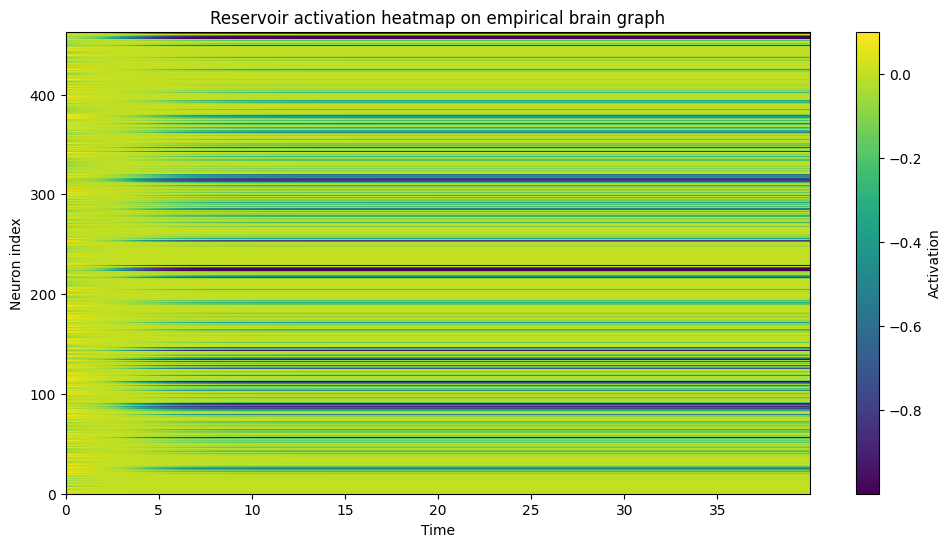

In [17]:
plt.figure(figsize=(12, 6))
plt.imshow(
    traj.T,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], 0, N]
)
plt.colorbar(label="Activation")
plt.xlabel("Time")
plt.ylabel("Neuron index")
plt.title("Reservoir activation heatmap on empirical brain graph")
plt.show()

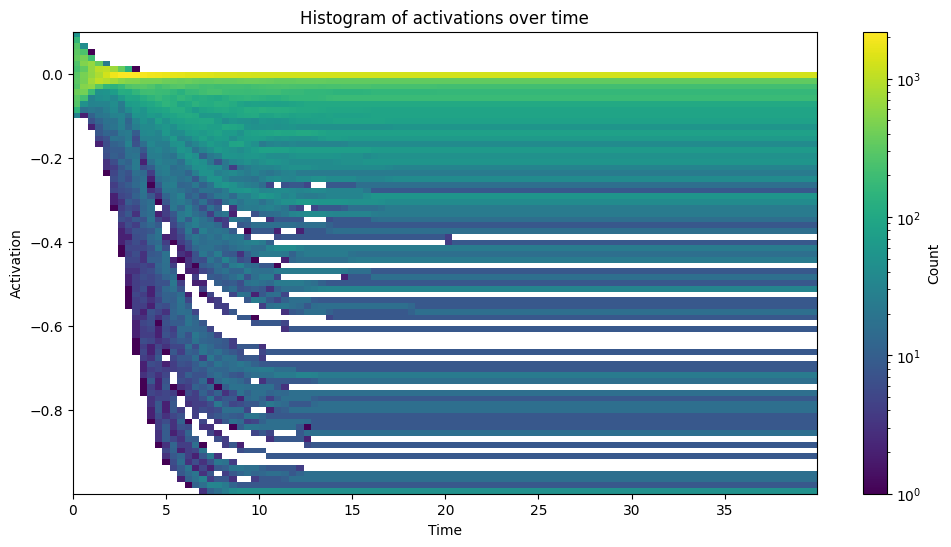

In [18]:
import matplotlib.colors as colors

n_times, n_neurons = traj.shape

time_vals = np.repeat(times, n_neurons)
activation_vals = traj.flatten()

plt.figure(figsize=(12, 6))
plt.hist2d(
    time_vals,
    activation_vals,
    bins=[100, 80],   # [time bins, activation bins]
    density=False,
    norm=colors.LogNorm()
)
plt.colorbar(label="Count")
plt.xlabel("Time")
plt.ylabel("Activation")
plt.title("Histogram of activations over time")
plt.show()

### Effect of spectral scaling on reservoir dynamics

We observed that the qualitative behavior of the reservoir dynamics strongly depends on the spectral scaling of the connectivity matrix. With a lower spectral radius, the system remains in a nearly linear regime, producing homogeneous and low-amplitude activations across neurons.

By increasing the spectral radius, the dynamics become significantly richer. The activation heatmap shows a broad distribution of values, with different neurons exhibiting distinct activity levels. This indicates that the system is effectively exploring the nonlinear regime of the activation function.

Additionally, after an initial transient phase, the dynamics settle into a structured pattern rather than becoming chaotic. This suggests that the empirical connectivity matrix supports stable yet heterogeneous activity, which is desirable for reservoir computing applications.

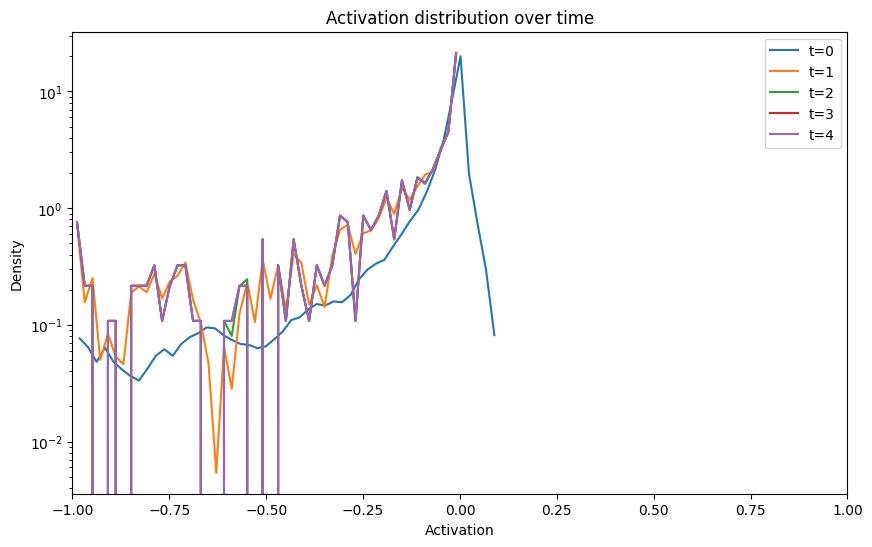

In [19]:
n_slices = 5
slice_size = len(traj) // n_slices

plt.figure(figsize=(10, 6))

for i in range(n_slices):
    start = i * slice_size
    end = (i + 1) * slice_size

    data = traj[start:end].flatten()

    counts, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(bin_centers, counts, label=f"t={i}")

plt.xlabel("Activation")
plt.ylabel("Density")
plt.yscale("log")
plt.title("Activation distribution over time")
plt.xlim(-1, 1)
plt.legend()
plt.show()

### Temporal evolution of activation distributions

To further characterize the reservoir dynamics, we analyzed the distribution of neuron activations at different time intervals. The resulting histograms show a pronounced peak around zero, indicating that most neurons remain in a low-activation regime.

At the same time, the presence of extended tails towards higher activation values reveals that a subset of neurons explores the nonlinear regime of the activation function. This indicates a balance between stability and expressivity in the system.

Over time, the distribution evolves from a more concentrated initial state to a broader configuration, before stabilizing. This behavior is consistent with a transient phase followed by a steady-state regime. The slight asymmetry observed in the distribution suggests that the underlying connectivity structure may influence the directionality of the dynamical responses.